In [1]:
import sys
!{sys.executable} -m pip install scikit-learn
print("✅ Scikit-Learn est installé !")

  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.6 MB 7.4 MB/s eta 0:00:05
   -- ------------------------------------- 2.4/36.6 MB 5.8 MB/s eta 0:00:06
   --- ------------------------------------ 3.1/36.6 MB 5.8 MB/s eta 0:00:06
   ---- ----------------------------------- 3.9/36.6 MB 4.7 MB/s eta 0:00:07
   ----- ---------------------------------- 5.2/36.6 MB 5.2 MB/s eta 0:00:06
   ----- ---------------------------------- 5.2/36.6 MB 5.2 MB/s eta 0:00:06
   ----- ---------------------------------- 5.2/36.6 MB 5.2 MB/s eta 0:00:06
   ------ --------------------------------- 5.5/36.6 MB 3.3 MB/

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("Préparation des données pour l'IA...")

# 1. Chargement des données
chemin_processed = "C:/Users/Lenovo/Desktop/Projet_IA_BI_Ecommerce/data/processed/"
df = pd.read_csv(chemin_processed + "dataset_propre.csv")

# 2. Création de la cible (y) : 1 = Mauvaise note (<= 2), 0 = Bonne note (>= 3)
df['mauvaise_note'] = (df['review_score'] <= 2).astype(int)

# 3. Sélection des variables explicatives (X)
colonnes_X = ['temps_livraison_jours', 'retard_livraison', 'price', 'freight_value']
X = df[colonnes_X]
y = df['mauvaise_note']

# 4. Découpage : 80% pour l'entraînement (Train) et 20% pour l'examen (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Données prêtes !")
print(f"L'IA va s'entraîner sur {X_train.shape[0]} commandes.")
print(f"L'IA sera évaluée sur {X_test.shape[0]} commandes.")


Préparation des données pour l'IA...
✅ Données prêtes !
L'IA va s'entraîner sur 86770 commandes.
L'IA sera évaluée sur 21693 commandes.


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Entraînement de l'Intelligence Artificielle en cours (cela peut prendre 10 à 30 secondes)...")

# 1. Création du modèle (On limite la profondeur à 10 pour que ce soit rapide)
modele_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# 2. Apprentissage (L'IA étudie les 86 770 commandes)
modele_rf.fit(X_train, y_train)
print("✅ Entraînement terminé !")

# 3. L'examen final : on lui demande de deviner les notes des 21 693 commandes de test
print("Évaluation en cours...")
predictions = modele_rf.predict(X_test)

# 4. Affichage des résultats
precision = accuracy_score(y_test, predictions)
print(f"\n🎯 Précision globale du modèle : {precision * 100:.2f}%")

print("\n📊 Rapport détaillé de l'examen :")
print(classification_report(y_test, predictions, target_names=['Bonne note (3-5)', 'Mauvaise note (1-2)']))


Entraînement de l'Intelligence Artificielle en cours (cela peut prendre 10 à 30 secondes)...
✅ Entraînement terminé !
Évaluation en cours...

🎯 Précision globale du modèle : 87.16%

📊 Rapport détaillé de l'examen :
                     precision    recall  f1-score   support

   Bonne note (3-5)       0.88      0.98      0.93     18517
Mauvaise note (1-2)       0.69      0.22      0.34      3176

           accuracy                           0.87     21693
          macro avg       0.79      0.60      0.63     21693
       weighted avg       0.85      0.87      0.84     21693



Analyse du cerveau de l'IA (Importance des variables)...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21952\2196514631.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance', y='Variable', palette='magma')


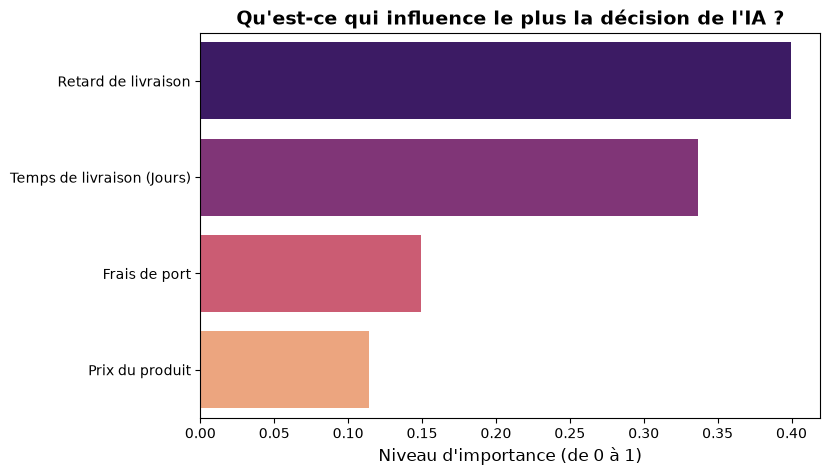

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Analyse du cerveau de l'IA (Importance des variables)...")

# Récupération de l'importance de chaque variable calculée par l'IA
importances = modele_rf.feature_importances_

# Création d'un petit tableau pour trier du plus important au moins important
df_importance = pd.DataFrame({
    'Variable': ['Temps de livraison (Jours)', 'Retard de livraison', 'Prix du produit', 'Frais de port'], 
    'Importance': importances
})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# Création du graphique
plt.figure(figsize=(8, 5))
sns.barplot(data=df_importance, x='Importance', y='Variable', palette='magma')

# Ajout des titres
plt.title("Qu'est-ce qui influence le plus la décision de l'IA ?", fontsize=14, fontweight='bold')
plt.xlabel("Niveau d'importance (de 0 à 1)", fontsize=12)
plt.ylabel("")

plt.show()


In [5]:
print("Ré-entraînement de l'IA avec la correction du déséquilibre...")

# 1. On recrée le modèle en ajoutant class_weight='balanced'
modele_rf_equilibre = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')

# 2. On ré-entraîne l'IA
modele_rf_equilibre.fit(X_train, y_train)
print("✅ Nouvel entraînement terminé !")

# 3. Le nouvel examen
predictions_equilibrees = modele_rf_equilibre.predict(X_test)

# 4. Affichage du nouveau rapport
print("\n📊 NOUVEAU Rapport détaillé :")
print(classification_report(y_test, predictions_equilibrees, target_names=['Bonne note (3-5)', 'Mauvaise note (1-2)']))


Ré-entraînement de l'IA avec la correction du déséquilibre...
✅ Nouvel entraînement terminé !

📊 NOUVEAU Rapport détaillé :
                     precision    recall  f1-score   support

   Bonne note (3-5)       0.90      0.92      0.91     18517
Mauvaise note (1-2)       0.45      0.39      0.42      3176

           accuracy                           0.84     21693
          macro avg       0.67      0.65      0.66     21693
       weighted avg       0.83      0.84      0.84     21693

